In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)

pd.set_option('display.max_rows',None)

#df = pd.read_csv("/content/drive/MyDrive/ai_impact_jobs_2010_2025.csv")
df = pd.read_csv("/content/drive/MyDrive/DataMining/ai_impact_jobs_2010_2025.csv")

display(df.head())

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,South America,London,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Middle East,Singapore,Future Solutions,Medium,Energy,Data Scientist,Executive,False,NaN,0.04,"Research, SQL, Business Analysis, Python, Clou...",NaN,62045,-3.98,0.71,False,High,19,Emerging
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,South Asia,Sydney,Future Analytics,Startup,Finance,Product Manager,Junior,False,NaN,0.15,"Statistics, Project Management, Cloud Computin...",NaN,27035,3.55,0.86,False,High,2,Emerging
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Europe,Nairobi,Global Technologies,Large,Government,Data Scientist,Mid,False,NaN,0.19,"Cloud Computing, SQL, Project Management, Comm...",NaN,72894,-2.80,0.70,False,Low,15,Emerging
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,East Asia,Sydney,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,NaN,0.11,"SQL, Python, Communication, Software Engineeri...",NaN,57215,0.85,0.87,False,High,13,Emerging


Se importan las librerías estándar para la manipulación estructural (Pandas, NumPy) y visualización (Matplotlib, Seaborn), y se carga el conjunto de datos en memoria para su posterior análisis exploratorio.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df.tail()

,job_id,posting_year,country,region,city,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage
4995,45aa223b-3ed6-4574-bd07-294a1443c02b,2022,Singapore,Southeast Asia,Bangalore,Prime Analytics,Enterprise,Education,ML Engineer,Intern,False,NaN,0.12,"SQL, Project Management, Data Analysis",NaN,41317,4.62,0.88,False,Low,17,Growing
4996,9f69f4ce-5fe9-44db-9541-478ebe28422b,2018,Chile,South America,Sydney,Future Analytics,Large,Healthcare,Policy Analyst,Senior,False,NaN,0.07,"Software Engineering, Statistics, Business Ana...",NaN,37089,-4.26,0.79,False,Low,13,Growing
4997,0ec6f97e-6dc3-468c-b2a2-ecc087bf067e,2019,Australia,Oceania,Bangalore,Global Solutions,Large,Education,ML Engineer,Mid,False,NaN,0.05,"Project Management, Data Analysis, Business An...",NaN,81651,-4.95,0.64,False,Low,19,Growing
4998,ad529cef-b22e-4e7d-82fd-98fc06d61596,2016,Sweden,Europe,Sydney,NextGen Systems,Enterprise,Energy,AI Researcher,Junior,True,"computer vision, MLOps",0.87,"SQL, Research, Cloud Computing, Communication,...","computer vision, MLOps",107897,-0.23,0.33,True,Low,14,Emerging
4999,79d26161-8cc1-4d98-ab0d-3ebea91f2a1b,2024,India,South Asia,Tokyo,Future Analytics,Enterprise,Tech,Software Engineer,Executive,True,LLMs,0.56,"Software Engineering, Project Management, Busi...",LLMs,35755,11.00,0.10,True,Low,11,Mature


In [6]:
df.shape

(5000, 22)

In [7]:
df.dtypes

,0
job_id,object
posting_year,int64
country,object
region,object
city,object
company_name,object
company_size,object
industry,object
job_title,object
seniority_level,object


**Mapeo de datos**

**job_id**: Identificador (Nominal)

**posting_year**: Numerico Discreto

**country**: Categorico Nominal

**region**: Categorico Nominal

**city**: Categorico Nominal

**company_name**: Categorico Nominal

**company_size**: Categorico Ordinal

**industry**: Categorico Nominal

**job_title**: Categorico Nominal

**seniority_level**: Categorico Ordinal

**ai_mentioned**: Booleano

**ai_keywords**: Categorico Nominal

**ai_intensity_score**: Numerico Continuo

**core_skills**: Categorico Nominal

**ai_skills**: Categorico Nominal

**salary_usd**: Numerico Continuo

**salary_change_vs_prev_year_percent**: Numerico Continuo

**automation_risk_score**: Numerico Continuo

**reskilling_required**: Booleano

**ai_job_displacement_risk**: Categorico Ordinal

**job_description_embedding_cluster**: Numerico Discreto

**industry_ai_adoption_stage**: Categorico Ordinal

### Clasificacion de Variables

* **Categorico Nominal**: Categorias sin un orden o jerarquia especifica.
  * Ejemplo: Region, Comuna, Genero.
* **Categorico Ordinal**: Categorias que siguen un orden logico o escala.
  * Ejemplo: Nivel educacional (Basica, Media, Superior).
* **Numerico Discreto**: Valores que surgen de un conteo y no admiten decimales.
  * Ejemplo: Cantidad de personas, Numero de hijos.
* **Numerico Continuo**: Valores que resultan de una medicion y pueden tener decimales infinitos.
  * Ejemplo: Estatura, Peso, Temperatura.

In [8]:
df.dropna()
df.isnull().sum()

,0
job_id,0
posting_year,0
country,0
region,0
city,0
company_name,0
company_size,0
industry,0
job_title,0
seniority_level,0


In [9]:
df['ai_keywords'] = df['ai_keywords'].fillna('')
df['ai_skills'] = df['ai_skills'].fillna('')

# Verifica que ya no haya valores nulos en estas columnas
display(df[['ai_keywords', 'ai_skills']].isnull().sum())

,0
ai_keywords,0
ai_skills,0


In [10]:
df.columns

Index(['job_id', 'posting_year', 'country', 'region', 'city', 'company_name',
       'company_size', 'industry', 'job_title', 'seniority_level',
       'ai_mentioned', 'ai_keywords', 'ai_intensity_score', 'core_skills',
       'ai_skills', 'salary_usd', 'salary_change_vs_prev_year_percent',
       'automation_risk_score', 'reskilling_required',
       'ai_job_displacement_risk', 'job_description_embedding_cluster',
       'industry_ai_adoption_stage'],
      dtype='object')

In [11]:
#Genera estadísticas descriptivas y redondea los valores resultantes al entero más cercano.
df.describe().round()

,posting_year,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,job_description_embedding_cluster
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2018.0,0.0,63096.0,3.0,1.0,9.0
std,5.0,0.0,31431.0,6.0,0.0,6.0
min,2010.0,0.0,15321.0,-5.0,0.0,0.0
25%,2013.0,0.0,36576.0,-2.0,0.0,4.0
50%,2017.0,0.0,60910.0,2.0,1.0,10.0
75%,2022.0,1.0,81812.0,5.0,1.0,14.0
max,2025.0,1.0,161547.0,18.0,1.0,19.0


In [12]:
df.shape

(5000, 22)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   job_id                              5000 non-null   object 
 1   posting_year                        5000 non-null   int64  
 2   country                             5000 non-null   object 
 3   region                              5000 non-null   object 
 4   city                                5000 non-null   object 
 5   company_name                        5000 non-null   object 
 6   company_size                        5000 non-null   object 
 7   industry                            5000 non-null   object 
 8   job_title                           5000 non-null   object 
 9   seniority_level                     5000 non-null   object 
 10  ai_mentioned                        5000 non-null   bool   
 11  ai_keywords                         5000 no

In [14]:
# Cuenta registros por industria y país,
# calcula promedios de salario y riesgo de automatización
# agrupados por industria, año y país para identificar patrones y tendencias.
df["industry"].value_counts()
df["country"].value_counts()
df.groupby("industry")["salary_usd"].mean()
df.groupby("posting_year")["salary_usd"].mean()
df.groupby("country")["automation_risk_score"].mean()

,automation_risk_score
country,
Argentina,0.575156
Australia,0.592989
Bangladesh,0.629794
Brazil,0.585210
Canada,0.555838
Chile,0.554034
China,0.574161
Colombia,0.585778
Egypt,0.589307


In [15]:
# Aplica one-hot encoding, creando columnas binarias para cada categoría
# y guarda el resultado. Luego muestra las primeras 5 filas para ver la transformación
df_encoded = pd.get_dummies(df, columns=['country', 'industry'], prefix=['country', 'industry'])
display(df_encoded.head())

,job_id,posting_year,region,city,company_name,company_size,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage,country_Argentina,country_Australia,country_Bangladesh,country_Brazil,country_Canada,country_Chile,country_China,country_Colombia,country_Egypt,country_France,country_Germany,country_Ghana,country_India,country_Indonesia,country_Israel,country_Italy,country_Japan,country_Jordan,country_Kenya,country_Malaysia,country_Mexico,country_Morocco,country_Nepal,country_Netherlands,country_New Zealand,country_Nigeria,country_Pakistan,country_Peru,country_Philippines,country_Poland,country_Qatar,country_Saudi Arabia,country_Singapore,country_South Africa,country_South Korea,country_Spain,country_Sri Lanka,country_Sweden,country_Taiwan,country_Thailand,country_UAE,country_United Kingdom,country_United States,country_Vietnam,industry_Agriculture,industry_Education,industry_Energy,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Retail,industry_Tech
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,South America,London,NextGen Technologies,Small,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,Middle East,Singapore,Future Solutions,Medium,Data Scientist,Executive,False,,0.04,"Research, SQL, Business Analysis, Python, Clou...",,62045,-3.98,0.71,False,High,19,Emerging,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,South Asia,Sydney,Future Analytics,Startup,Product Manager,Junior,False,,0.15,"Statistics, Project Management, Cloud Computin...",,27035,3.55,0.86,False,High,2,Emerging,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Europe,Nairobi,Global Technologies,Large,Data Scientist,Mid,False,,0.19,"Cloud Computing, SQL, Project Management, Comm...",,72894,-2.80,0.70,False,Low,15,Emerging,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,East Asia,Sydney,Future Technologies,Small,ML Engineer,Lead,False,,0.11,"SQL, Python, Communication, Software Engineeri...",,57215,0.85,0.87,False,High,13,Emerging,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False


clasificacion de variables ver

In [16]:
cant_cat_col_country_df = df['country'].value_counts() # nos mostrará la cantidad de categorías distintas únicas de 'country'
print(cant_cat_col_country_df)

# Imprimimos la cantidad total de categorías únicas
print(f"Cantidad de países únicos: {cant_cat_col_country_df.count()}")

country
Australia         281
New Zealand       255
United States     207
Mexico            193
Canada            185
Taiwan            159
Japan             138
China             137
Colombia          135
South Korea       130
Argentina         128
Saudi Arabia      125
Chile             119
Brazil            119
Sri Lanka         117
UAE               117
Pakistan          115
Nepal             112
Israel            106
Qatar             104
Egypt             101
Malaysia          101
Peru              100
India              99
Bangladesh         97
Vietnam            97
Philippines        97
Ghana              93
Jordan             89
Kenya              88
Indonesia          87
Nigeria            87
Thailand           84
Singapore          83
United Kingdom     80
South Africa       80
Morocco            80
Sweden             77
Netherlands        75
France             72
Italy              66
Germany            65
Poland             62
Spain              58
Name: count, dtype: int6

In [17]:
df.describe().round()

,posting_year,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,job_description_embedding_cluster
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2018.0,0.0,63096.0,3.0,1.0,9.0
std,5.0,0.0,31431.0,6.0,0.0,6.0
min,2010.0,0.0,15321.0,-5.0,0.0,0.0
25%,2013.0,0.0,36576.0,-2.0,0.0,4.0
50%,2017.0,0.0,60910.0,2.0,1.0,10.0
75%,2022.0,1.0,81812.0,5.0,1.0,14.0
max,2025.0,1.0,161547.0,18.0,1.0,19.0


In [43]:
pip install category_encoders

In [19]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [20]:
ohe = OneHotEncoder(sparse_output=False)
region_encoded = ohe.fit_transform(df[['region']])

# Convertimos el resultado en un DataFrame con nombres de columnas claros
region_df = pd.DataFrame(
    region_encoded,
    columns=ohe.get_feature_names_out(['region']),
    index=df.index
)

# Display the head of the new DataFrame
display(region_df.head())

,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# Codificación binaria para la columna 'city' usando Category Encoders
# Este codificador es adecuado para columnas con alta cardinalidad.
be = ce.BinaryEncoder(cols=['city'])
df_binary_city = be.fit_transform(df['city'])

# Concatenar todo y eliminar las columnas originales
# Unir el DataFrame original (sin 'region' y 'city') con las nuevas columnas
df_final = pd.concat([df.drop(columns=['region', 'city']), region_df, df_binary_city], axis=1)

# Verificar los cambios
display(df_final.head())
print(f"Total de columnas después de la codificación: {len(df_final.columns)}")

,job_id,posting_year,country,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Future Solutions,Medium,Energy,Data Scientist,Executive,False,,0.04,"Research, SQL, Business Analysis, Python, Clou...",,62045,-3.98,0.71,False,High,19,Emerging,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,Future Analytics,Startup,Finance,Product Manager,Junior,False,,0.15,"Statistics, Project Management, Cloud Computin...",,27035,3.55,0.86,False,High,2,Emerging,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,1
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Global Technologies,Large,Government,Data Scientist,Mid,False,,0.19,"Cloud Computing, SQL, Project Management, Comm...",,72894,-2.80,0.70,False,Low,15,Emerging,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,,0.11,"SQL, Python, Communication, Software Engineeri...",,57215,0.85,0.87,False,High,13,Emerging,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1


Total columns after encoding: 33


In [22]:
# Codificación binaria para la columna 'city' usando Category Encoders
# Este codificador es adecuado para columnas con alta cardinalidad.
be = ce.BinaryEncoder(cols=['city'])
df_binary_city = be.fit_transform(df['city'])

# Concatenar todo y eliminar las columnas originales
# Unir el DataFrame original (sin 'region' y 'city') con las nuevas columnas
df_final = pd.concat([df.drop(columns=['region', 'city']), region_df, df_binary_city], axis=1)

# Verificar los cambios
display(df_final.head())
print(f"Total de columnas después de la codificación: {len(df_final.columns)}")

,job_id,posting_year,country,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Future Solutions,Medium,Energy,Data Scientist,Executive,False,,0.04,"Research, SQL, Business Analysis, Python, Clou...",,62045,-3.98,0.71,False,High,19,Emerging,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,Future Analytics,Startup,Finance,Product Manager,Junior,False,,0.15,"Statistics, Project Management, Cloud Computin...",,27035,3.55,0.86,False,High,2,Emerging,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,1
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Global Technologies,Large,Government,Data Scientist,Mid,False,,0.19,"Cloud Computing, SQL, Project Management, Comm...",,72894,-2.80,0.70,False,Low,15,Emerging,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,,0.11,"SQL, Python, Communication, Software Engineeri...",,57215,0.85,0.87,False,High,13,Emerging,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1


Total columns after encoding: 33


In [23]:
df_final.head(100)

,job_id,posting_year,country,company_name,company_size,industry,job_title,seniority_level,ai_mentioned,ai_keywords,ai_intensity_score,core_skills,ai_skills,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,ai_job_displacement_risk,job_description_embedding_cluster,industry_ai_adoption_stage,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
0,836b4774-702e-49ef-93d3-2f255ce1e910,2018,Brazil,NextGen Technologies,Small,Education,Policy Analyst,Lead,True,reinforcement learning,0.81,"Research, Project Management, Business Analysis",reinforcement learning,61586,12.68,0.11,True,Low,14,Growing,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
1,43699e93-7b15-4728-a4c6-9e41ff438a25,2015,UAE,Future Solutions,Medium,Energy,Data Scientist,Executive,False,,0.04,"Research, SQL, Business Analysis, Python, Clou...",,62045,-3.98,0.71,False,High,19,Emerging,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
2,fc9d1854-3cbf-4bab-90df-77304dfc59df,2016,Nepal,Future Analytics,Startup,Finance,Product Manager,Junior,False,,0.15,"Statistics, Project Management, Cloud Computin...",,27035,3.55,0.86,False,High,2,Emerging,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,1
3,05c1c7d3-2add-4919-91eb-f6c78bfe23d1,2015,Spain,Global Technologies,Large,Government,Data Scientist,Mid,False,,0.19,"Cloud Computing, SQL, Project Management, Comm...",,72894,-2.80,0.70,False,Low,15,Emerging,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
4,5e739937-d1b0-44d7-935c-7ebb3fc1f6e8,2014,Taiwan,Future Technologies,Small,Manufacturing,ML Engineer,Lead,False,,0.11,"SQL, Python, Communication, Software Engineeri...",,57215,0.85,0.87,False,High,13,Emerging,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1
5,3eaa8f95-6ada-4e08-ad17-ca924707d66f,2022,Colombia,Future Analytics,Enterprise,Government,ML Engineer,Senior,True,deep learning,0.77,"Cloud Computing, Research, Data Analysis",deep learning,67379,8.47,0.29,True,High,3,Growing,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1
6,1da6731c-2a17-4fde-b43a-3281912bc31d,2016,Jordan,Prime Systems,Medium,Healthcare,Software Engineer,Mid,False,,0.11,"Project Management, Python, Communication, Clo...",,63931,0.30,0.60,False,Low,15,Emerging,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
7,85cccc9e-f1c0-4b09-80c0-ab91b09d6f6b,2014,Peru,NextGen Solutions,Large,Healthcare,Systems Engineer,Executive,False,,0.03,"Software Engineering, Research, Communication,...",,39525,1.07,0.89,False,Low,2,Emerging,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,1
8,2e7cd904-6aaf-4138-9464-1ad4971c25bf,2017,India,Prime Technologies,Startup,Education,Policy Analyst,Junior,True,deep learning,0.44,"Project Management, Software Engineering, Busi...",deep learning,29117,-1.70,0.25,True,High,13,Growing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,1,0
9,bcf3fde0-b3e8-457f-9b90-fa1716e92bae,2023,Sri Lanka,Global Technologies,Startup,Government,AI Researcher,Junior,False,,0.20,"Data Analysis, Business Analysis, Communicatio...",,24450,-0.97,0.70,False,Low,14,Growing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,1,1


In [24]:
df_final.describe().round()

,posting_year,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,job_description_embedding_cluster,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2018.0,0.0,63096.0,3.0,1.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
std,5.0,0.0,31431.0,6.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
min,2010.0,0.0,15321.0,-5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2013.0,0.0,36576.0,-2.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,2017.0,0.0,60910.0,2.0,1.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
75%,2022.0,1.0,81812.0,5.0,1.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
max,2025.0,1.0,161547.0,18.0,1.0,19.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


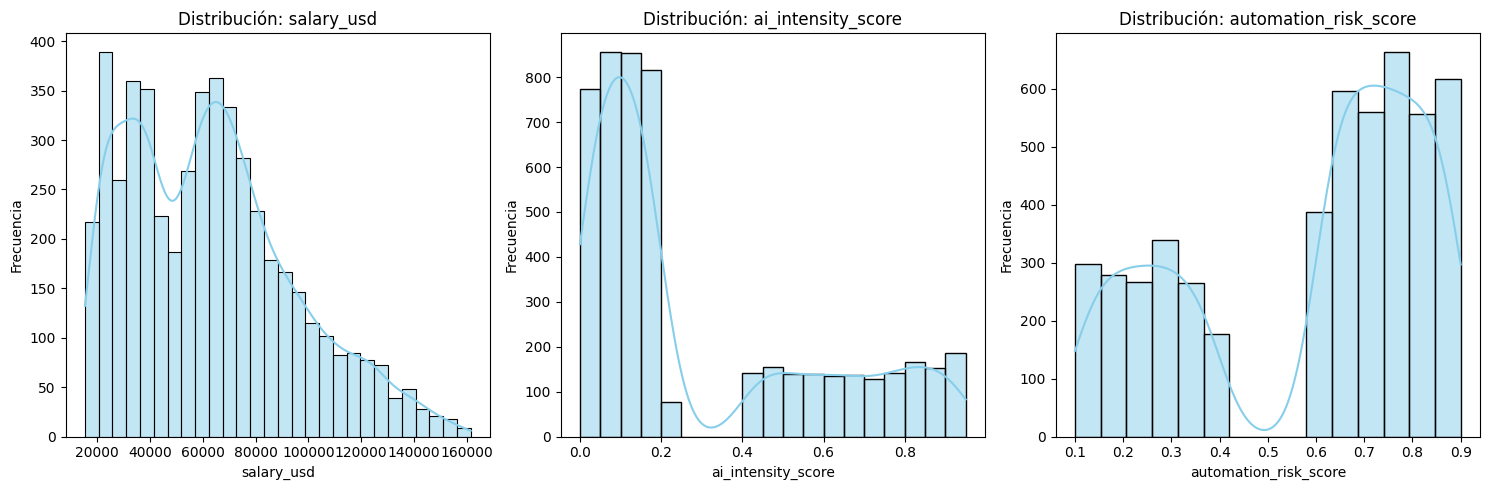

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_numericas_recomendadas = [
    'salary_usd',
    'ai_intensity_score',
    'automation_risk_score'
]

plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_numericas_recomendadas, 1): # permite asignar cada variable a su subplot correspondiente
    plt.subplot(1, 3, i) # 1 fila, 3 columnas
    # Histograma con curva de densidad
    sns.histplot(df_final[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout() # evita que se superpongan los elementos.
plt.show()

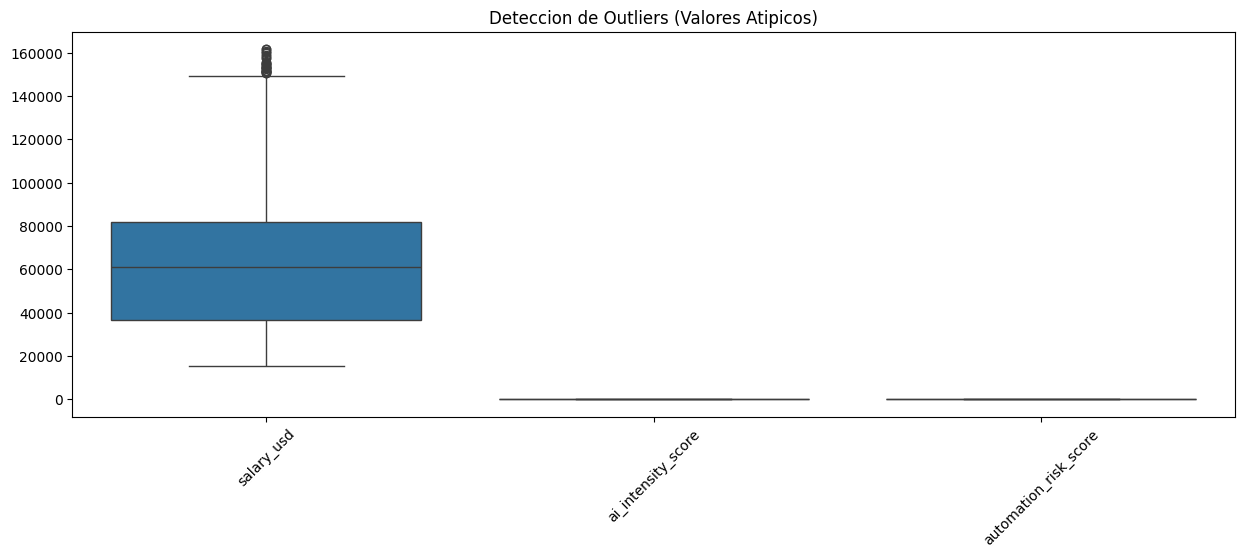

In [26]:
# Boxplot para detectar Outliers
plt.figure(figsize=(15, 5))
sns.boxplot(data=df_final[cols_numericas_recomendadas])
plt.xticks(rotation=45)
plt.title('Deteccion de Outliers (Valores Atipicos)')
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler

# Las columnas numéricas recomendadas que existen en df_final
cols_a_escalar = [
    'salary_usd',
    'ai_intensity_score',
    'automation_risk_score'
]

# Inicializamos el escalador
scaler = StandardScaler()

# Aplicamos el escalamiento a df_final
# Usamos una copia para mantener la integridad de los datos originales si es necesario
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final_esc[cols_a_escalar])

# Verificacion rapida
print("Primeras 5 filas con datos estandarizados:")
display(df_final_esc[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados:


,salary_usd,ai_intensity_score,automation_risk_score
0,-0.048052,1.794032,-1.904845
1,-0.033447,-0.848854,0.495333
2,-1.147418,-0.471298,1.095377
3,0.311753,-0.334006,0.455330
4,-0.187131,-0.608591,1.135380


In [28]:
# Seleccionamos solo las columnas numéricas para calcular la correlación
df_numeric = df_final_esc.select_dtypes(include=['number', 'bool'])
display(df_numeric.corr())

,posting_year,ai_mentioned,ai_intensity_score,salary_usd,salary_change_vs_prev_year_percent,automation_risk_score,reskilling_required,job_description_embedding_cluster,region_Africa,region_East Asia,region_Europe,region_Middle East,region_North America,region_Oceania,region_South America,region_South Asia,region_Southeast Asia,city_0,city_1,city_2,city_3
posting_year,1.000000,0.446476,0.413547,0.386976,0.496052,-0.422360,0.446476,0.013785,-0.005434,-0.006399,-0.025843,-0.015408,0.020681,0.026428,-0.003204,0.015077,-0.005952,0.010573,-0.002871,0.000358,0.023028
ai_mentioned,0.446476,1.000000,0.933263,0.457716,0.720072,-0.938291,1.000000,0.014589,0.001787,-0.005501,-0.009726,-0.002212,0.020079,0.004162,0.007770,-0.019658,0.002452,0.004001,0.003956,0.006542,0.001657
ai_intensity_score,0.413547,0.933263,1.000000,0.419280,0.668776,-0.875102,0.933263,0.009501,0.010918,-0.005347,-0.007207,-0.010510,0.025570,-0.004281,0.001299,-0.016872,0.005699,-0.002710,0.002829,0.004693,0.001593
salary_usd,0.386976,0.457716,0.419280,1.000000,0.377662,-0.431737,0.457716,0.010445,-0.414848,0.156732,0.219564,0.072960,0.423478,0.316914,-0.164078,-0.389811,-0.234865,-0.009366,0.016920,-0.004221,-0.004727
salary_change_vs_prev_year_percent,0.496052,0.720072,0.668776,0.377662,1.000000,-0.676072,0.720072,0.008555,0.010381,-0.004955,-0.010602,-0.008259,0.012796,0.015821,-0.002025,-0.014923,0.001770,-0.012001,0.014683,0.004493,0.004702
automation_risk_score,-0.422360,-0.938291,-0.875102,-0.431737,-0.676072,1.000000,-0.938291,-0.016966,-0.003036,0.008236,0.011976,-0.001214,-0.021190,-0.002975,-0.002440,0.021021,-0.009777,-0.001712,-0.006741,-0.012691,0.000817
reskilling_required,0.446476,1.000000,0.933263,0.457716,0.720072,-0.938291,1.000000,0.014589,0.001787,-0.005501,-0.009726,-0.002212,0.020079,0.004162,0.007770,-0.019658,0.002452,0.004001,0.003956,0.006542,0.001657
job_description_embedding_cluster,0.013785,0.014589,0.009501,0.010445,0.008555,-0.016966,0.014589,1.000000,0.020111,0.009374,-0.006149,-0.018133,0.024388,-0.019404,0.009814,-0.009127,-0.012095,-0.021116,0.000794,-0.007377,-0.022144
region_Africa,-0.005434,0.001787,0.010918,-0.414848,0.010381,-0.003036,0.001787,0.020111,1.000000,-0.122650,-0.121545,-0.119813,-0.125210,-0.119192,-0.127141,-0.119689,-0.120804,-0.011343,-0.010517,0.012479,0.009430
region_East Asia,-0.006399,-0.005501,-0.005347,0.156732,-0.004955,0.008236,-0.005501,0.009374,-0.122650,1.000000,-0.125995,-0.124201,-0.129795,-0.123556,-0.131797,-0.124072,-0.125228,0.004592,0.000389,-0.005096,0.002444


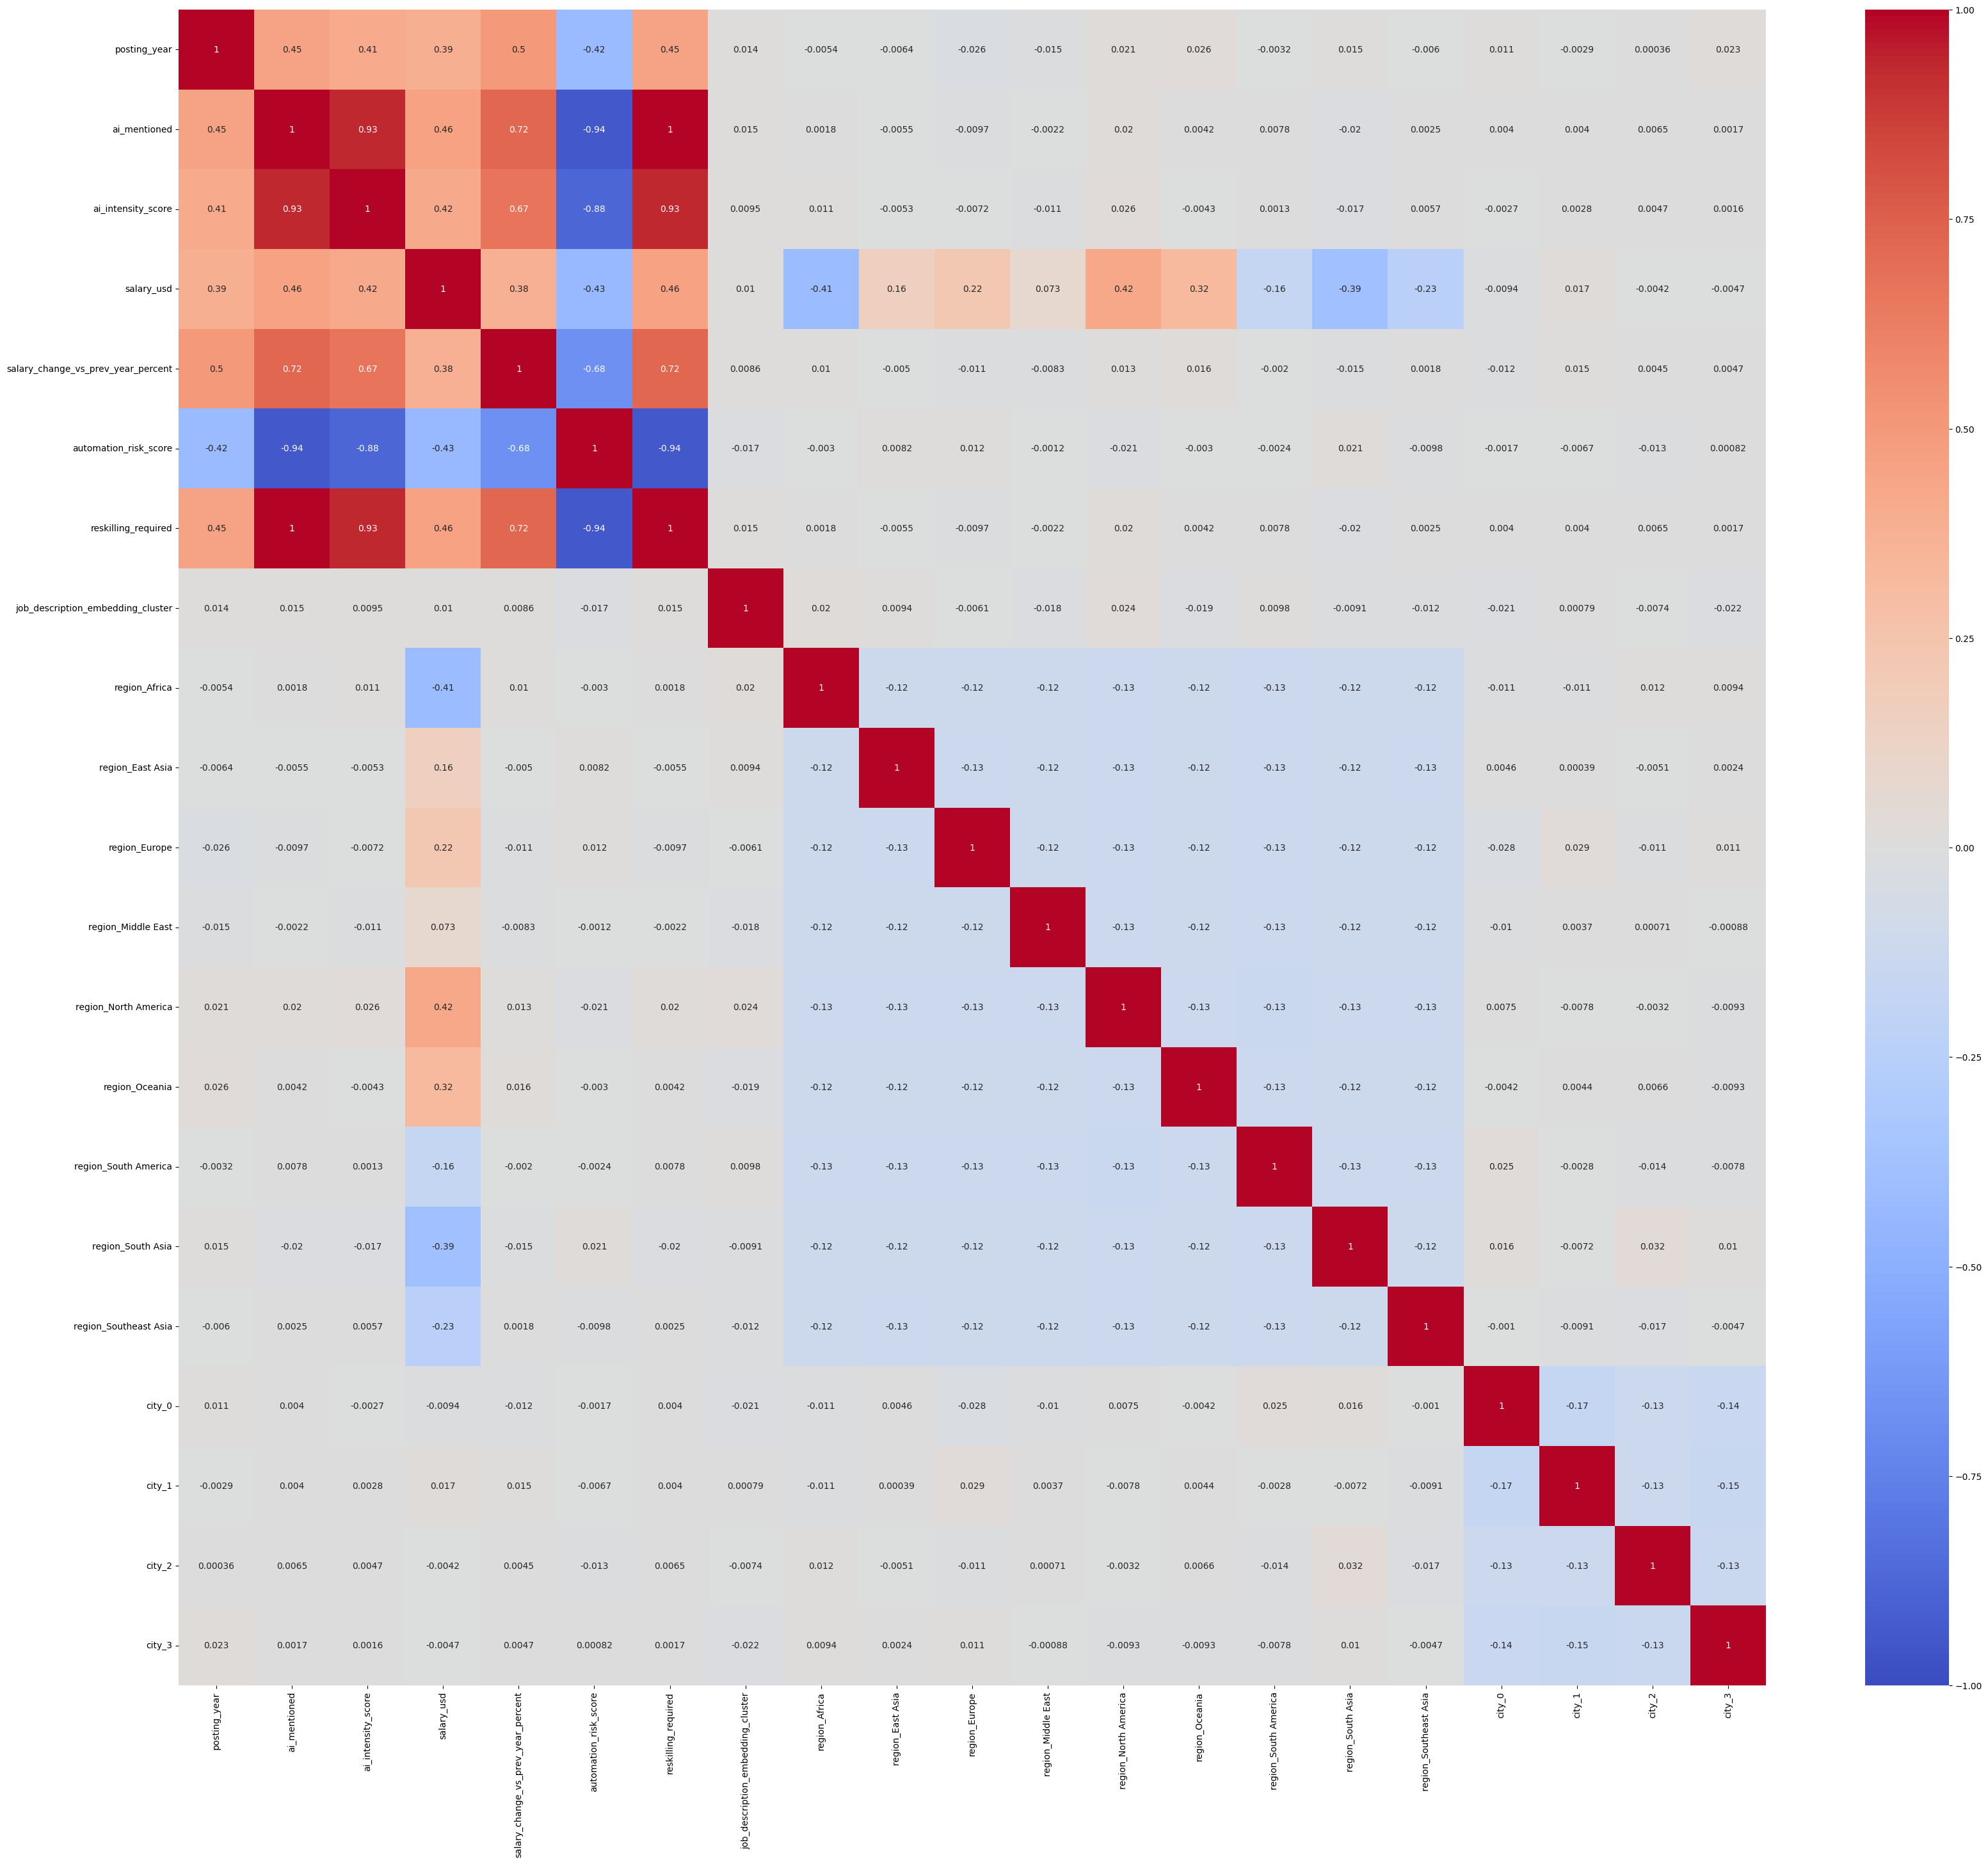

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df_numeric.corr() # Usamos df_numeric que ya contiene solo las columnas numéricas

plt.figure(figsize=(40, 34))

sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [31]:
regiones= df['region']
display(regiones.head())

,region
0,South America
1,Middle East
2,South Asia
3,Europe
4,East Asia


In [32]:
#Calcula el salario promedio por región y redondea
average_salary_by_region = df.groupby('region')['salary_usd'].mean().round(1).reset_index()
display(average_salary_by_region)

,region,salary_usd
0,Africa,25192.5
1,East Asia,76910.6
2,Europe,82624.7
3,Middle East,69679.2
4,North America,99658.8
5,Oceania,91839.6
6,South America,49145.0
7,South Asia,27888.0
8,Southeast Asia,42078.7


In [33]:
# Agrupar por región, cargo y nivel de seniority para obtener el salario promedio
avg_salary_multi = df.groupby(['region', 'job_title', 'seniority_level'])['salary_usd'].mean().round(1).reset_index()

# Ordenar por región y salario para mejor visualización
avg_salary_multi = avg_salary_multi.sort_values(by=['region', 'salary_usd'], ascending=[True, False])

display(avg_salary_multi.head(20))
# Si deseas ver el dataframe completo, puedes usar display(avg_salary_multi)

,region,job_title,seniority_level,salary_usd
8,Africa,Business Analyst,Junior,29166.1
2,Africa,AI Researcher,Junior,29047.5
40,Africa,Product Manager,Mid,28066.4
33,Africa,Policy Analyst,Lead,27986.6
20,Africa,ML Engineer,Junior,27894.0
5,Africa,AI Researcher,Senior,27773.2
43,Africa,Research Scientist,Intern,27491.1
47,Africa,Research Scientist,Senior,27490.1
56,Africa,Systems Engineer,Junior,27073.0
44,Africa,Research Scientist,Junior,27052.9


In [34]:
# Obtener el top 3 de salarios promedio por cada región
top_3_by_region = avg_salary_multi.groupby('region').head(3)

# Mostrar el resultado
display(top_3_by_region)

,region,job_title,seniority_level,salary_usd
8,Africa,Business Analyst,Junior,29166.1
2,Africa,AI Researcher,Junior,29047.5
40,Africa,Product Manager,Mid,28066.4
85,East Asia,Operations Manager,Intern,103027.7
71,East Asia,Business Analyst,Senior,89921.2
82,East Asia,ML Engineer,Mid,87922.7
162,Europe,Research Scientist,Executive,101982.3
142,Europe,ML Engineer,Mid,95799.8
153,Europe,Policy Analyst,Lead,93682.1
212,Middle East,Policy Analyst,Junior,91433.2


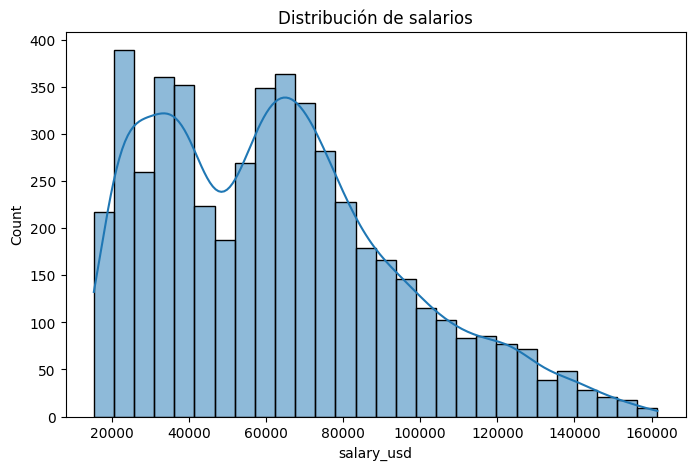

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configura las dimensiones del lienzo del gráfico
plt.figure(figsize=(8,5))

# Genera un histograma con la curva de densidad de probabilidad (KDE)
sns.histplot(df['salary_usd'], kde=True)
plt.title('Distribución de salarios')

plt.show()

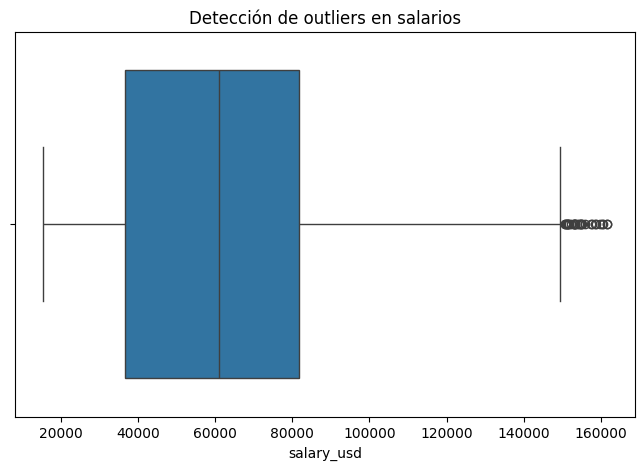

In [36]:
plt.figure(figsize=(8,5))
# Genera un diagrama de caja horizontal para la columna de salarios
sns.boxplot(x=df['salary_usd'])
plt.title('Detección de outliers en salarios')
plt.show()

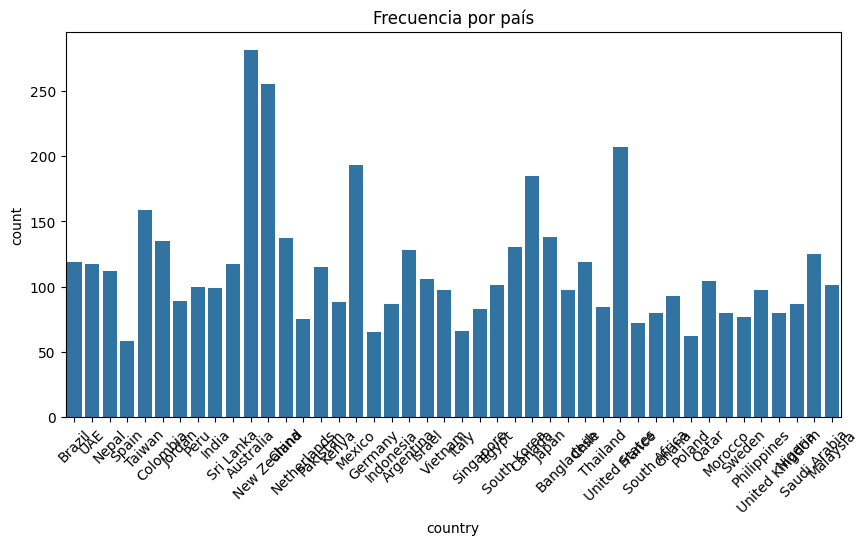

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(x='country', data=df)
plt.xticks(rotation=45)
plt.title('Frecuencia por país')
plt.show()

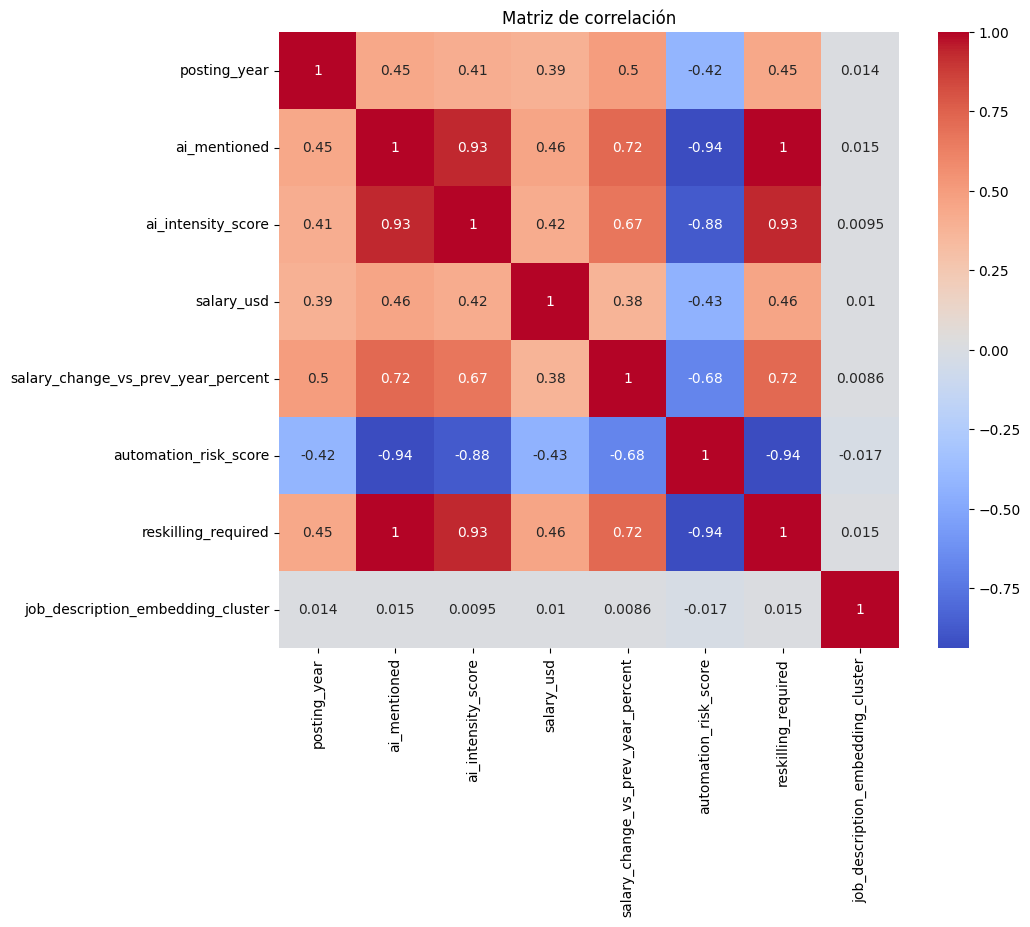

In [38]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

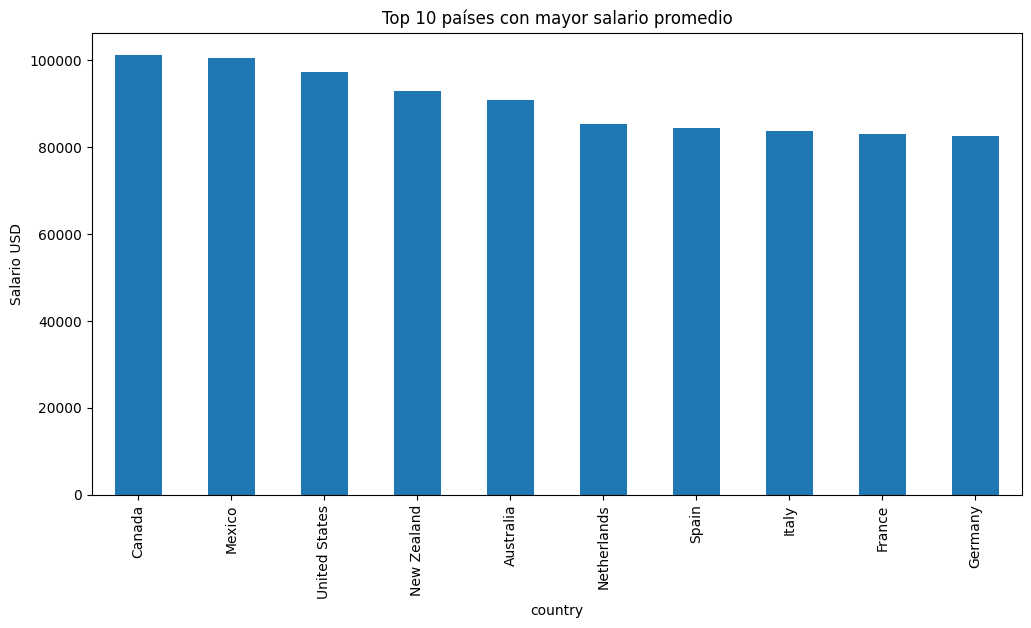

In [39]:
# Agrupa por país, calcula el salario promedio, y ordena los resultados de mayor a menor
df_country = df.groupby('country')['salary_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

# Crea un gráfico con los 10 primeros países de mayor salario
df_country.head(10).plot(kind='bar')

plt.title('Top 10 países con mayor salario promedio')
plt.ylabel('Salario USD')

plt.show()

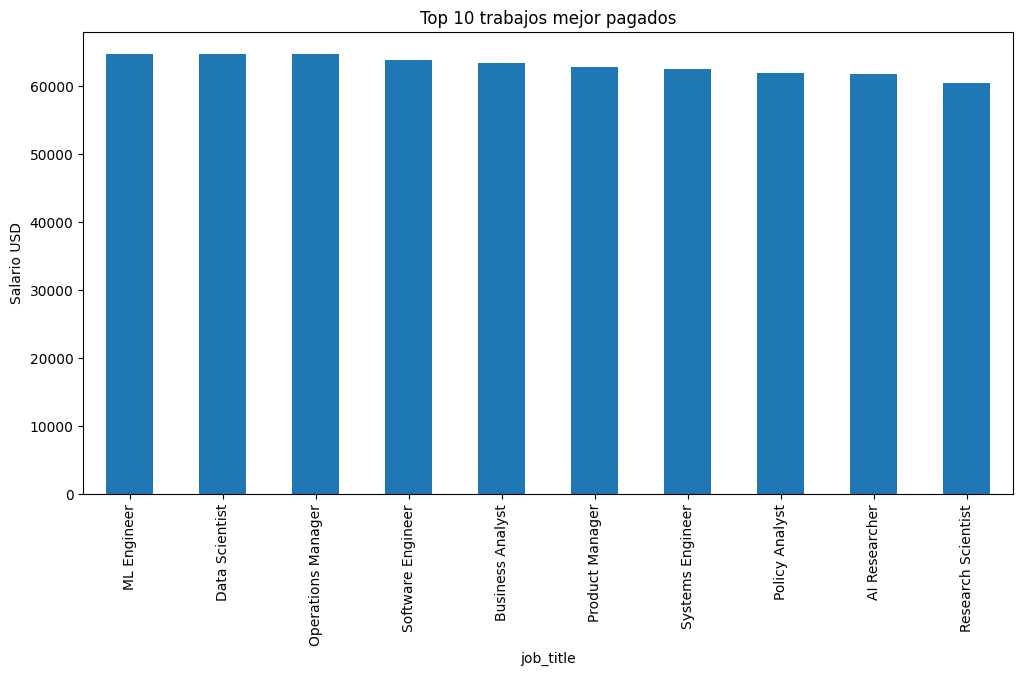

In [40]:
# Agrupa por título de trabajo, calcula el salario promedio y ordena de mayor a menor
df_job = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))

#Muestra en un gráfico los 10 primeros puestos de mejor pagados
df_job.head(10).plot(kind='bar')

plt.title('Top 10 trabajos mejor pagados')
plt.ylabel('Salario USD')

plt.show()

In [41]:
# Calcula el primer cuartil (el valor que deja por debajo al 25% de los datos)
Q1 = df['salary_usd'].quantile(0.25)

# Calcula el tercer cuartil (el valor que deja por debajo al 75% de los datos)
Q3 = df['salary_usd'].quantile(0.75)

# Calcula el Rango Intercuartílico (la diferencia entre Q3 y Q1)
IQR = Q3 - Q1

# Filtra el DataFrame buscando valores que estén por debajo del límite inferior
# o por encima del límite superior. El símbolo '|' significa 'O' lógico.
outliers = df[(df['salary_usd'] < Q1 - 1.5*IQR) | (df['salary_usd'] > Q3 + 1.5*IQR)]

# Imprime la cantidad total de filas (outliers) que cumplieron la condición anterior
print("Cantidad de outliers:", outliers.shape[0])

Cantidad de outliers: 30


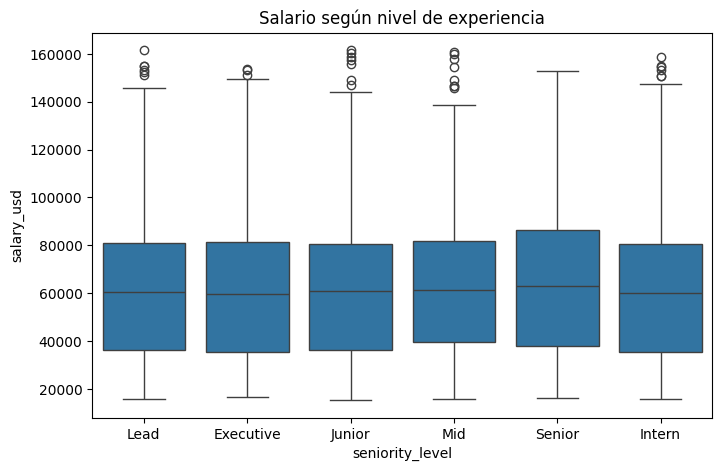

In [42]:
plt.figure(figsize=(8,5))

# Crea un diagrama de caja múltiple cruzando categorías (experiencia) con los salarios
sns.boxplot(x='seniority_level', y='salary_usd', data=df)
plt.title('Salario según nivel de experiencia')

plt.show()